2026-05-04 11:45:49.589811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777895149.766787      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777895149.816288      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777895150.208454      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777895150.208501      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777895150.208503      23 computation_placer.cc:177] computation placer alr

Found 17580 files belonging to 30 classes.


I0000 00:00:1777895181.326047      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 2514 files belonging to 30 classes.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

[PHASE 1] WARM-UP: Đóng băng EfficientNet, học Dense + GeM
Epoch 1/5


E0000 00:00:1777895201.655161      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
Corrupt JPEG data: 229 extraneous bytes before marker 0xd9
Corrupt JPEG data: 9 extraneous bytes before marker 0xe2
I0000 00:00:1777895289.346103      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


550/550 ━━━━━━━━━━━━━━━━━━━━ 157s 98ms/step - loss: 0.3873 - val_loss: 0.3897
Epoch 2/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - loss: 0.3695 - val_loss: 0.3622
Epoch 3/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - loss: 0.3681 - val_loss: 0.3714
Epoch 4/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - loss: 0.3616 - val_loss: 0.3499
Epoch 5/5
550/550 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - loss: 0.3547 - val_loss: 0.3475

[PHASE 2] FINE-TUNING: Mở 30 lớp cuối, AdamW LR=5e-5
Epoch 1/50


E0000 00:00:1777895532.104347      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb2_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


550/550 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - loss: 0.3934 - val_loss: 0.3533 - learning_rate: 5.0000e-05
Epoch 2/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - loss: 0.3444 - val_loss: 0.3393 - learning_rate: 5.0000e-05
Epoch 3/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - loss: 0.3326 - val_loss: 0.3311 - learning_rate: 5.0000e-05
Epoch 4/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - loss: 0.3251 - val_loss: 0.3233 - learning_rate: 5.0000e-05
Epoch 5/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - loss: 0.3161 - val_loss: 0.3157 - learning_rate: 5.0000e-05
Epoch 6/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 52s 94ms/step - loss: 0.3026 - val_loss: 0.3036 - learning_rate: 5.0000e-05
Epoch 7/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 50s 91ms/step - loss: 0.3007 - val_loss: 0.3050 - learning_rate: 5.0000e-05
Epoch 8/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - loss: 0.2983 - val_loss: 0.2965 - learning_rate: 5.0000e-05
Epoch 9/50
550/550 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - loss: 0.2882 - val_loss: 0

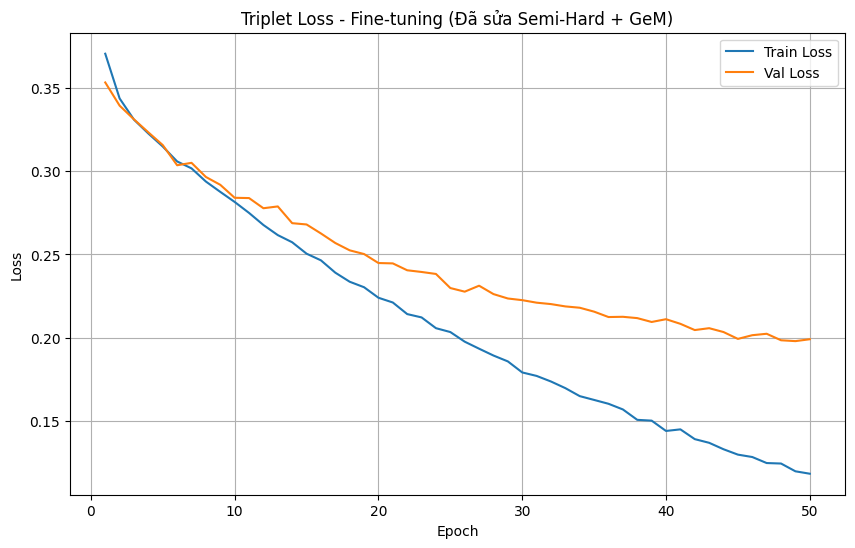

In [1]:
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# ==========================================
# 1. CẤU HÌNH
# ==========================================
BASE_PATH = "/kaggle/input/datasets/anos22/dataset-vn-food-30"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_WARMUP = 5
EPOCHS_FINETUNE = 50
VECTOR_DIM = 512

def find_data_path(base_path):
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs and 'val' in dirs:
            return root
    return base_path

DATA_DIR = find_data_path(BASE_PATH)
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")

# ==========================================
# 2. LỚP GeM POOLING (Chuẩn công nghiệp, chống nổ Gradient và hỗ trợ lưu file)
# ==========================================
@tf.keras.utils.register_keras_serializable()
class GeMPooling(layers.Layer):
    def __init__(self, p=3.0, eps=1e-6, trainable_p=True, **kwargs):
        super().__init__(**kwargs)
        self.p_init = p
        self.eps = eps
        self.trainable_p = trainable_p

    def build(self, input_shape):
        self.p = self.add_weight(
            name='gem_power',
            shape=(),
            initializer=tf.keras.initializers.Constant(self.p_init),
            trainable=self.trainable_p,
            dtype=tf.float32
        )
        super().build(input_shape)

    def call(self, inputs):
        # Cộng epsilon để tránh nổ gradient khi pixel có giá trị 0
        x = tf.maximum(inputs, self.eps)
        x = tf.pow(x, self.p)
        # Pooling gộp theo không gian ảnh (h, w)
        x = tf.reduce_mean(x, axis=[1, 2], keepdims=False)
        x = tf.pow(x, 1.0 / self.p)
        return x

    def get_config(self):
        # Bắt buộc phải có để model.save() và load_model() hoạt động
        config = super().get_config()
        config.update({
            "p": self.p_init,
            "eps": self.eps,
            "trainable_p": self.trainable_p
        })
        return config

# ==========================================
# 3. HÀM TRIPLET LOSS (SEMI-HARD MINING CHÍNH XÁC)
#    - Sửa lỗi "max" → "min" trong chọn negative semi-hard
#    - Margin an toàn 0.5
# ==========================================
def custom_triplet_loss(margin=0.5):
    def triplet_loss(y_true, y_pred):
        y_true = tf.cast(tf.squeeze(y_true), tf.int32)
        embeddings = y_pred   # đã qua UnitNormalization

        # Khoảng cách Euclidean bình phương
        dot_product = tf.matmul(embeddings, embeddings, transpose_b=True)
        square_norm = tf.linalg.diag_part(dot_product)
        distances = tf.expand_dims(square_norm, 1) - 2.0 * dot_product + tf.expand_dims(square_norm, 0)
        distances = tf.maximum(distances, 0.0)

        labels_equal = tf.equal(tf.expand_dims(y_true, 0), tf.expand_dims(y_true, 1))
        mask_positive = tf.cast(labels_equal, tf.float32) - tf.eye(tf.shape(y_true)[0])
        mask_negative = 1.0 - tf.cast(labels_equal, tf.float32)

        # Hardest positive
        hardest_positive_dist = tf.reduce_max(distances * mask_positive, axis=1, keepdims=True)

        # ---- Semi-Hard Negative Mining (đúng công thức) ----
        # Điều kiện semi-hard: D(a, p) < D(a, n) < D(a, p) + margin
        semi_hard_condition = tf.logical_and(
            distances > hardest_positive_dist,
            distances < hardest_positive_dist + margin
        )
        # Chỉ áp dụng cho negative
        semi_hard_mask = tf.cast(semi_hard_condition, tf.float32) * mask_negative

        # Nếu không có semi-hard thì dùng hardest negative toàn cục
        max_dist = tf.reduce_max(distances, axis=1, keepdims=True)
        hardest_negative_fallback = tf.reduce_min(
            distances + max_dist * (1.0 - mask_negative), axis=1, keepdims=True
        )

        # Trong vùng semi-hard, negative khó nhất là điểm có khoảng cách NHỎ NHẤT (gần anchor nhất)
        # sau khi loại bỏ các điểm không thoả mãn (gán chúng bằng giá trị cực lớn)
        masked_for_min = tf.where(
            tf.cast(semi_hard_mask, tf.bool),
            distances,
            tf.fill(tf.shape(distances), tf.constant(1e9, dtype=distances.dtype))
        )
        hardest_semi_hard = tf.reduce_min(masked_for_min, axis=1, keepdims=True)

        # Nếu giá trị tìm được vẫn là 1e9 (nghĩa là không có semi-hard) -> dùng fallback
        has_semi_hard = tf.cast(hardest_semi_hard < 1e8, tf.float32)
        hardest_negative_dist = (
            has_semi_hard * hardest_semi_hard + (1 - has_semi_hard) * hardest_negative_fallback
        )
        # ----------------------------------------------

        loss = tf.maximum(hardest_positive_dist - hardest_negative_dist + margin, 0.0)
        return tf.reduce_mean(loss)

    return triplet_loss

# ==========================================
# 4. PIPELINE DỮ LIỆU
# ==========================================
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(height_factor=(-0.2, 0.2), width_factor=(-0.2, 0.2)),
    layers.RandomContrast(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 5. KIẾN TRÚC MÔ HÌNH
# ==========================================
base_model = EfficientNetB2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)

# --- GeM Pooling thay cho GAP ---
x = GeMPooling(p=3.0, trainable_p=True)(x)
# ---------------------------------

x = layers.Dropout(0.5)(x)
x = layers.Dense(
    VECTOR_DIM,
    activation=None,
    kernel_regularizer=regularizers.l2(1e-4)
)(x)
outputs = layers.UnitNormalization(axis=1)(x)
model = tf.keras.Model(inputs, outputs)

# ==========================================
# 6. HUẤN LUYỆN 2 GIAI ĐOẠN
# ==========================================

# --- GIAI ĐOẠN 1: WARM-UP ---
print("\n[PHASE 1] WARM-UP: Đóng băng EfficientNet, học Dense + GeM")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=custom_triplet_loss(margin=0.5)   # margin an toàn 0.5
)
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_WARMUP
)

# --- GIAI ĐOẠN 2: FINE-TUNING ---
print("\n[PHASE 2] FINE-TUNING: Mở 30 lớp cuối, AdamW LR=5e-5")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-5, weight_decay=1e-4),
    loss=custom_triplet_loss(margin=0.5)
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("/kaggle/working/best_model_fixed.keras", monitor='val_loss', save_best_only=True)
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks
)

model.save("/kaggle/working/vietnamese_food_extractor_fixed.keras")
print("\n--- HOÀN TẤT ---")

# ==========================================
# 7. VẼ BIỂU ĐỒ
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history.history['loss'])+1), history.history['loss'], label='Train Loss')
plt.plot(range(1, len(history.history['val_loss'])+1), history.history['val_loss'], label='Val Loss')
plt.title('Triplet Loss - Fine-tuning (Đã sửa Semi-Hard + GeM)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/training_curve_fixed.png", dpi=300)